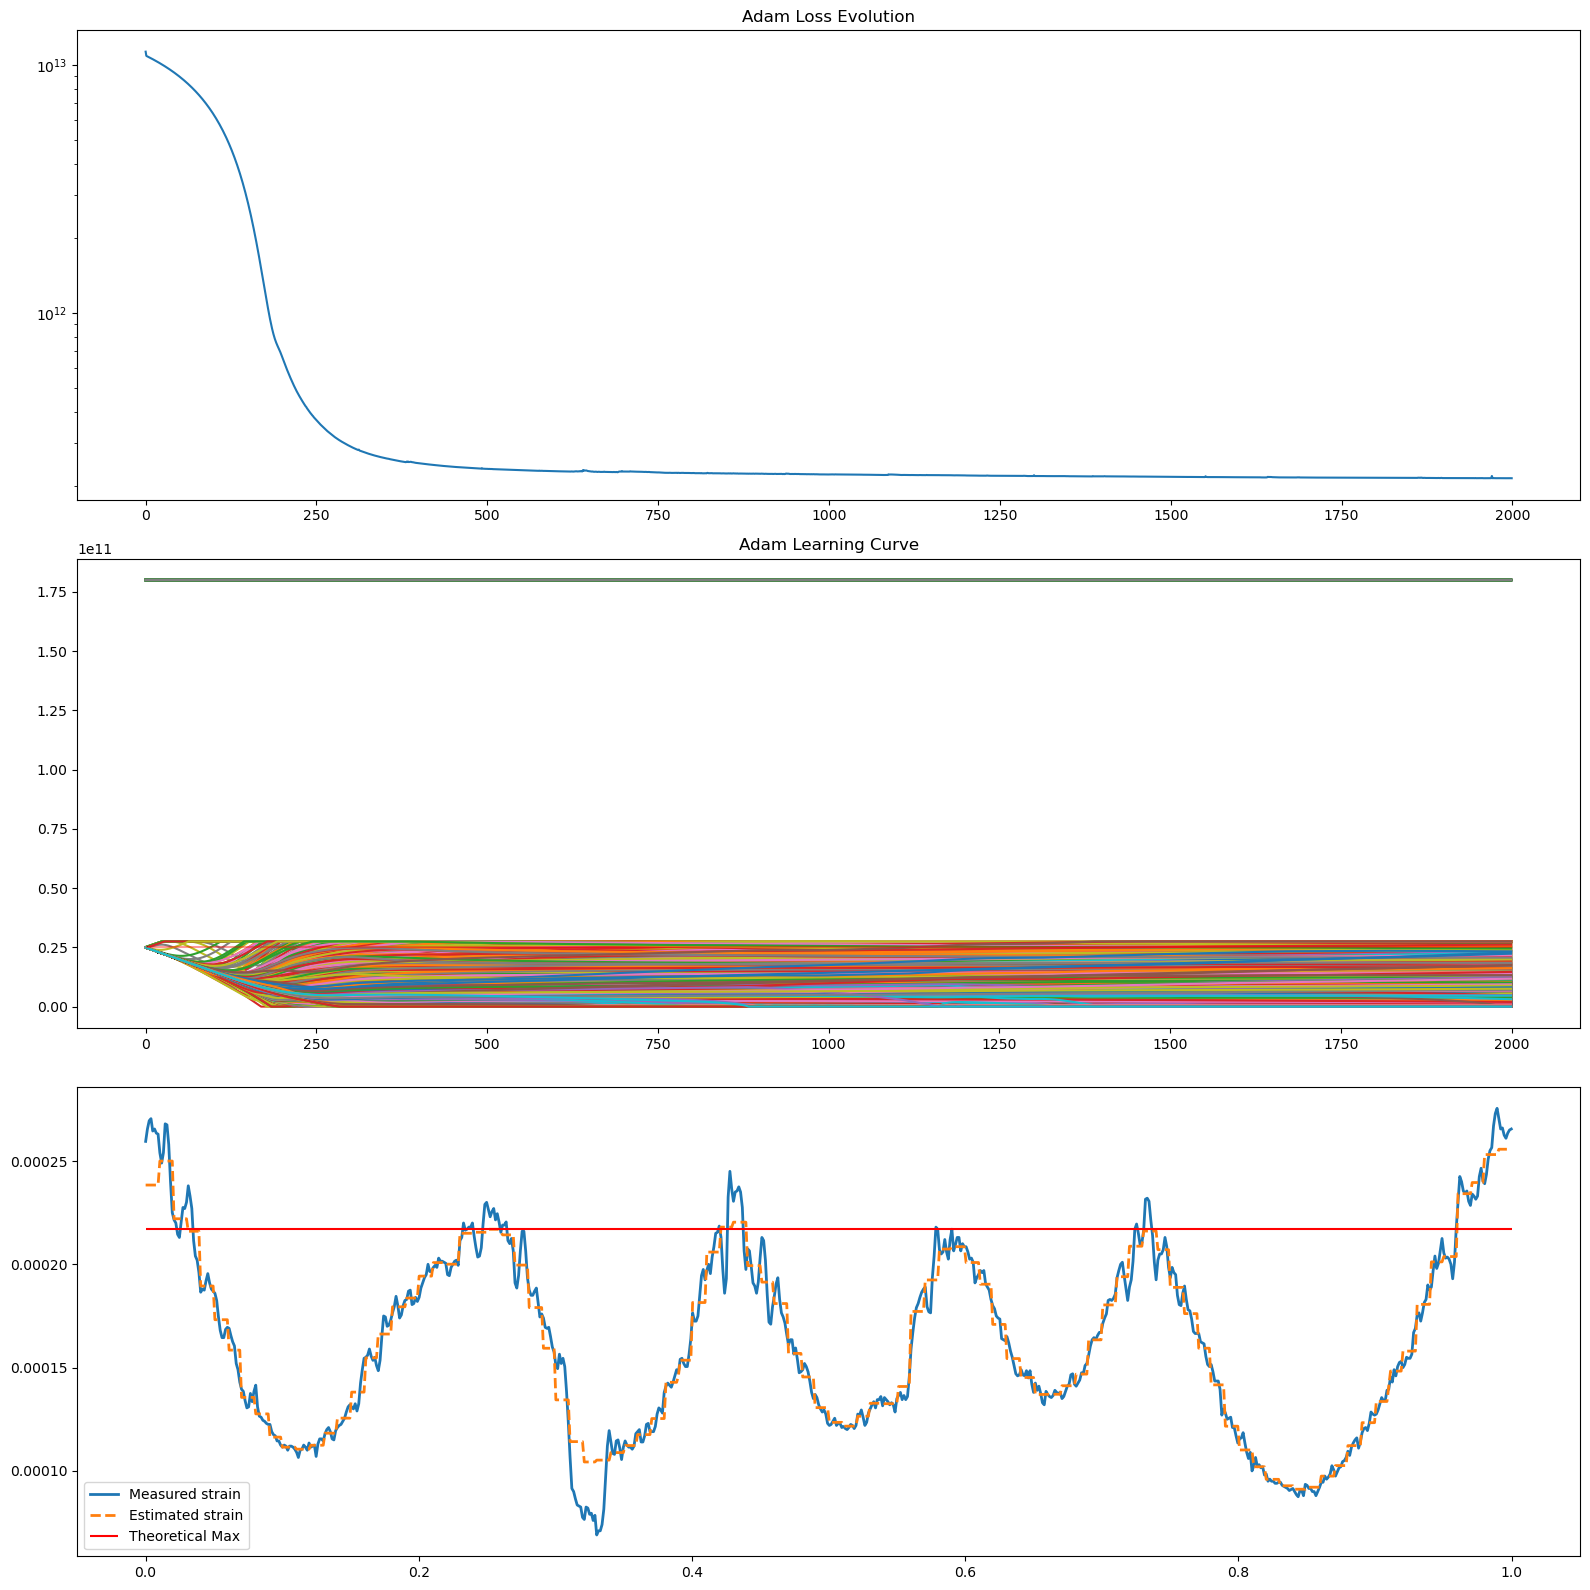

C:\Users\Jeffrey\AppData\Local\Temp\ipykernel_6678664\4054232824.py:185: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


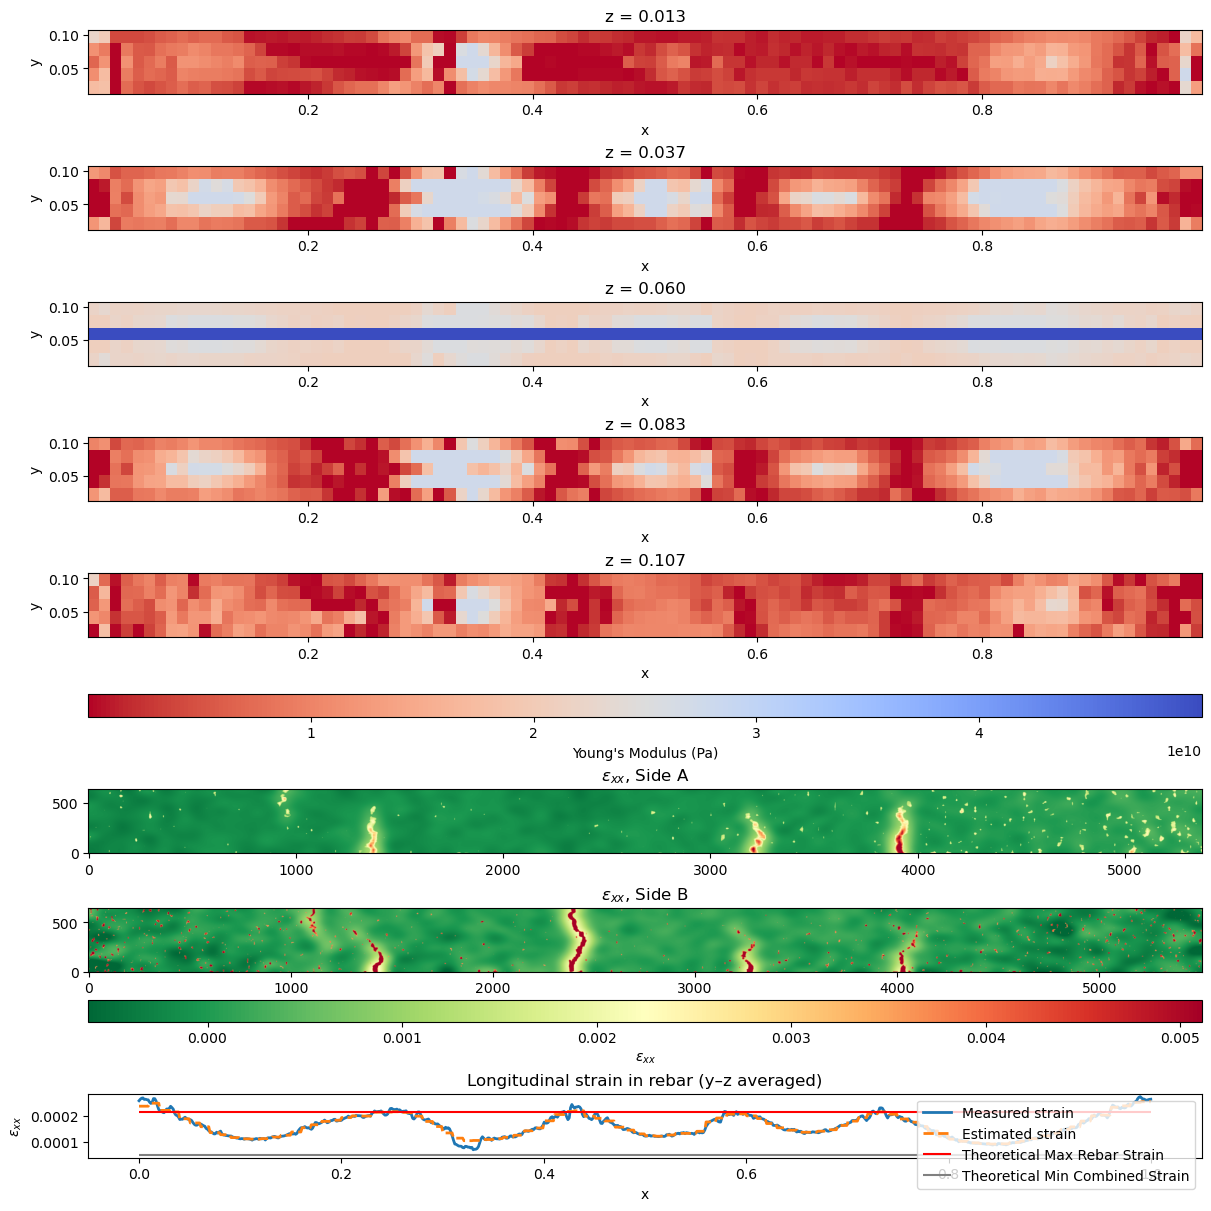

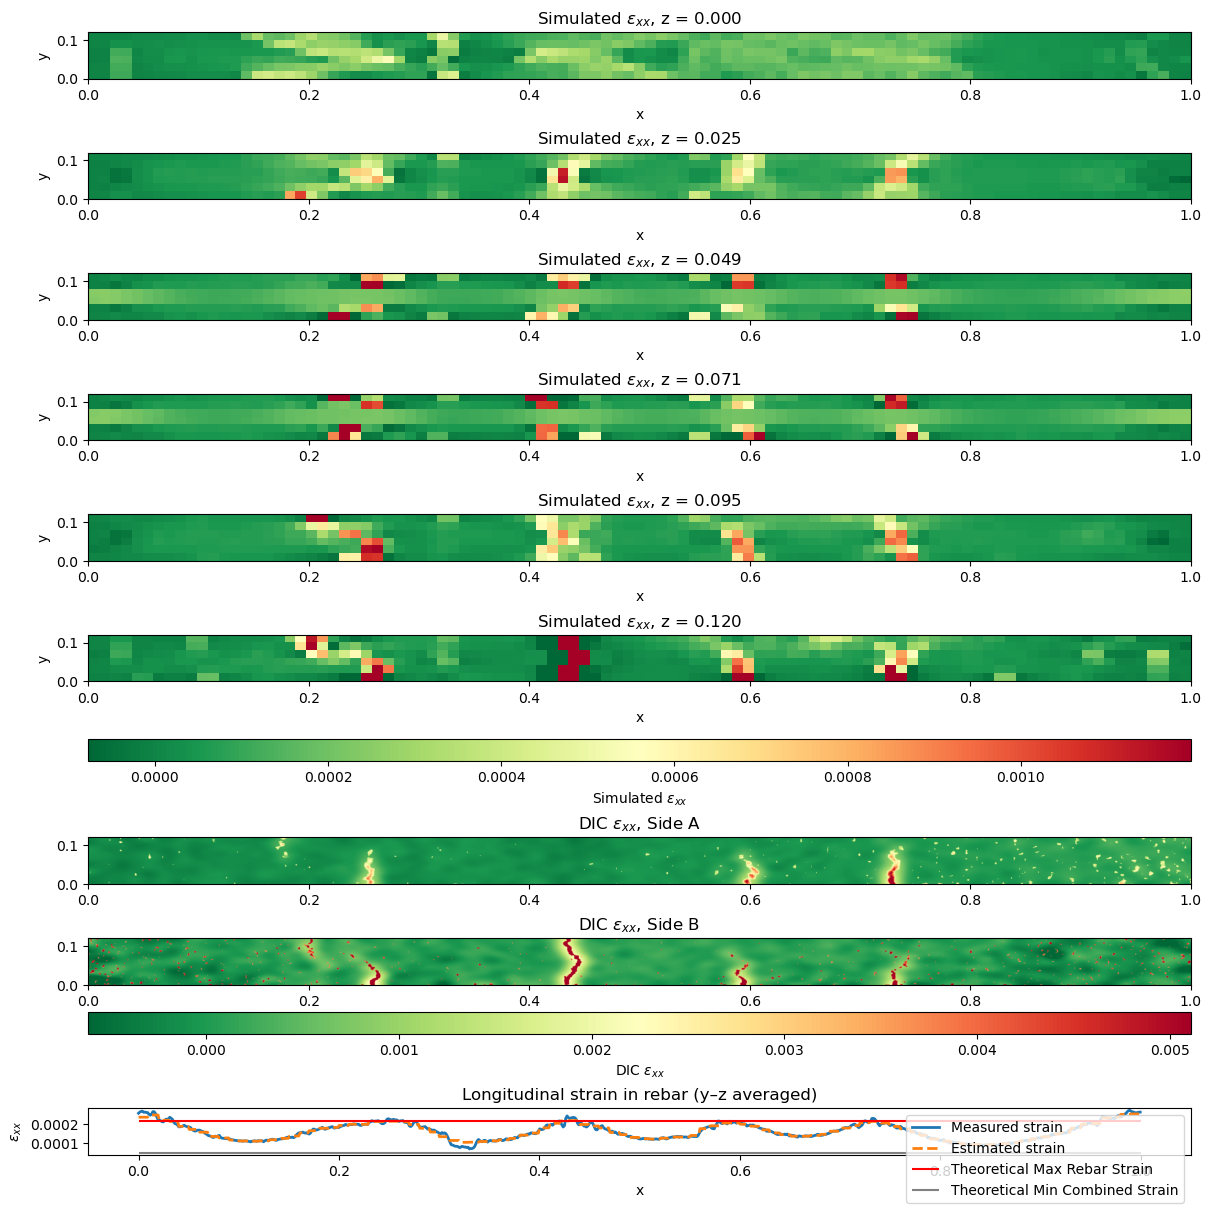

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
import pyvista
from matplotlib import cm
import matplotlib.cbook as cbook
import matplotlib.colors as colors

exp_names = [i[:-9] for i in os.listdir('plot_data')]

for exp_name in exp_names:
    data = np.load(f"plot_data/{exp_name}_data.npz", allow_pickle=True)

    # 2. EXTRACT DATA
    # Metadata
    meta = data['metadata'].item()

    # Optimization & History
    losses = data['losses']
    params = data['params']
    n_its = len(losses)

    # Experimental / Reference
    strain_meas = data['strain_meas']
    strain_meas_x = data['strain_meas_x']
    Exx_A = data['Exx_A']
    Exx_B = data['Exx_B']
    theoretical_displacement = data['theoretical_displacement']
    theoretical_displacement_rebar = data['theoretical_displacement_rebar']

    # Geometry & Fields
    node_positions = data['node_positions']
    E_best = data['E_best']
    strain_best = data['strain_best']
    strain_res = data['strain_res']
    x_s_unique = data['x_s_unique']
    eps_est_avg = data['eps_est_avg']

    # Mesh Info
    cells = data['vtk_cells']
    cell_types = data['vtk_types']

    # Re-derive coordinate helpers
    x_nodes, y_nodes, z_nodes = node_positions[:, 0], node_positions[:, 1], node_positions[:, 2]
    z_unique = np.unique(np.round(z_nodes, decimals=6))

    # --- FIGURE 1: LOSS & LEARNING CURVES ---
    fig, axes = plt.subplots(3, 1, figsize=(16, 16))

    axes[0].plot(np.arange(n_its), losses)
    axes[0].set_title('Adam Loss Evolution')
    axes[0].set_yscale('log')

    axes[1].plot(np.arange(n_its), params)
    axes[1].hlines(25e9, 0, n_its, color='r', alpha=0.4, label="Baseline Concrete")
    axes[1].set_title('Adam Learning Curve')

    axes[2].plot(strain_meas_x, strain_meas, label="Measured strain", lw=2)
    axes[2].plot(x_s_unique, eps_est_avg, label="Estimated strain", lw=2, linestyle="--")
    axes[2].hlines(theoretical_displacement_rebar, 0, 1, color='r', label="Theoretical Max")
    axes[2].legend()
    plt.tight_layout()
    plt.savefig(f"D:/Research/Masonry-Rail/4 DiffFEM/{exp_name}_LC.png", dpi=300)

    # --- FIGURE 2: YOUNG'S MODULUS SLICES (E_best) ---
    # Reconstruct PyVista grid to get cell centers for slicing
    grid = pyvista.UnstructuredGrid(cells, cell_types, node_positions)
    grid.cell_data["values"] = E_best
    centers = grid.cell_centers().points
    x_c, y_c, z_c = centers[:,0], centers[:,1], centers[:,2]
    z_unique = np.unique(z_c)

    fig, axes = plt.subplots(len(z_unique)+3, 1, figsize=(12, 12), layout='constrained')

    im_E_list = []
    im_strain_list = []

    # --- Shared scale for E fields ---
    E_min = np.min(E_best)
    E_max = np.max(E_best)
    vmin_E = E_min
    vmax_E = 27.0e9
    # vmax_E = E_max

    # --- Shared scale for strain fields ---
    vmin_strain = min(np.nanpercentile(Exx_A, 1), np.nanpercentile(Exx_B, 1))
    vmax_strain = max(np.nanpercentile(Exx_A, 99), np.nanpercentile(Exx_B, 99))

    # --- 3D slices (E fields) ---
    for i, zi in enumerate(z_unique):
        mask = np.isclose(z_c, zi)
        E_val = grid.cell_data["values"][mask]
        coords = centers[mask][:, :2]

        x_vals = coords[:, 0]
        y_vals = coords[:, 1]

        x_unique = np.unique(x_vals)
        y_unique = np.unique(y_vals)

        grid_E = np.full((len(y_unique), len(x_unique)), np.nan)

        x_idx = np.searchsorted(x_unique, x_vals)
        y_idx = np.searchsorted(y_unique, y_vals)

        grid_E[y_idx, x_idx] = E_val

        ax = axes[i]
        im = ax.imshow(
            grid_E,
            origin='lower',
            extent=[x_unique.min(), x_unique.max(), y_unique.min(), y_unique.max()],
            cmap='coolwarm_r',
            norm=colors.CenteredNorm(vcenter=25e9),
            # vmin=vmin_E,
            # vmax=vmax_E,
            aspect='auto'
        )

        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_title(f'z = {zi:.3f}')

        im_E_list.append(im)

    # --- Strain images ---
    idx_A = len(z_unique)
    idx_B = len(z_unique) + 1

    imA = axes[idx_A].imshow(
        Exx_A,
        origin='lower',
        cmap='RdYlGn_r',
        # norm=colors.CenteredNorm(vcenter=),
        vmin=vmin_strain,
        vmax=vmax_strain,
        aspect='auto',
    )
    axes[idx_A].set_title(r'$\epsilon_{xx}$, Side A')

    imB = axes[idx_B].imshow(
        Exx_B,
        origin='lower',
        cmap='RdYlGn_r',
        vmin=vmin_strain,
        vmax=vmax_strain,
        aspect='auto',
    )
    axes[idx_B].set_title(r'$\epsilon_{xx}$, Side B')

    im_strain_list.extend([imA, imB])

    # --- Colorbar for E fields ---
    cbar_E = fig.colorbar(
        im_E_list[0],
        ax=axes[:len(z_unique)],
        orientation='horizontal',
        pad=0.02,
        aspect=50
    )
    cbar_E.set_label("Young's Modulus (Pa)")

    # --- Colorbar for strain fields ---
    cbar_strain = fig.colorbar(
        im_strain_list[0],
        ax=axes[len(z_unique):len(z_unique)+2],
        orientation='horizontal',
        pad=0.02,
        aspect=50
    )
    cbar_strain.set_label(r'$\epsilon_{xx}$')



    # --- Bottom plot ---
    ax = axes[len(z_unique)+2]
    ax.plot(strain_meas_x, strain_meas, label="Measured strain", lw=2)
    ax.plot(x_s_unique, eps_est_avg, label="Estimated strain", lw=2, linestyle="--")
    ax.hlines(theoretical_displacement_rebar, 0, 1, color='r', label="Theoretical Max Rebar Strain")
    ax.hlines(theoretical_displacement, 0, 1, color='0.5', label="Theoretical Min Combined Strain")
    ax.set_xlabel("x")
    ax.set_ylabel(r"$\varepsilon_{xx}$")
    ax.set_title("Longitudinal strain in rebar (y–z averaged)")
    ax.legend()
    plt.savefig(f"D:/Research/Masonry-Rail/4 DiffFEM/{exp_name}_E.png", dpi=300)

    # --- FIGURE 3: STRAIN SLICES ---
    # --- Node data ---
    nodes = node_positions  # (N, 3)
    x_nodes = nodes[:, 0]
    y_nodes = nodes[:, 1]
    z_nodes = nodes[:, 2]

    # --- Simulated strain (nodal) ---
    strain_xx = strain_res[:, 0, 0]

    # Robust z slicing (handle float precision)
    z_unique = np.unique(np.round(z_nodes, decimals=6))
    n_slices = len(z_unique)

    fig, axes = plt.subplots(n_slices + 3, 1, figsize=(12, 12), layout='constrained')

    im_strain3D_list = []
    im_dic_list = []

    # --- Scales ---
    vmin_sim = np.nanpercentile(strain_xx, 1)
    vmax_sim = np.nanpercentile(strain_xx, 99)

    vmin_dic = min(np.nanpercentile(Exx_A, 1), np.nanpercentile(Exx_B, 1))
    vmax_dic = max(np.nanpercentile(Exx_A, 99), np.nanpercentile(Exx_B, 99))

    # --- 3D strain slices (NODE-BASED) ---
    for i, zi in enumerate(z_unique):
        mask = np.isclose(z_nodes, zi)

        strain_val = strain_xx[mask]
        x_vals = x_nodes[mask]
        y_vals = y_nodes[mask]

        x_unique = np.unique(x_vals)
        y_unique = np.unique(y_vals)

        grid_strain = np.full((len(y_unique), len(x_unique)), np.nan)

        x_idx = np.searchsorted(x_unique, x_vals)
        y_idx = np.searchsorted(y_unique, y_vals)

        grid_strain[y_idx, x_idx] = strain_val

        ax = axes[i]
        im = ax.imshow(
            grid_strain,
            origin='lower',
            extent=[x_unique.min(), x_unique.max(), y_unique.min(), y_unique.max()],
            cmap='RdYlGn_r',
            vmin=vmin_sim,
            vmax=vmax_sim,
            aspect='auto'
        )

        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_title(f'Simulated $\\epsilon_{{xx}}$, z = {zi:.3f}')

        im_strain3D_list.append(im)

    # --- Use last slice extent for alignment ---
    x_min, x_max = x_unique.min(), x_unique.max()
    y_min, y_max = y_unique.min(), y_unique.max()

    # --- DIC strain images ---
    idx_A = n_slices
    idx_B = n_slices + 1

    imA = axes[idx_A].imshow(
        Exx_A,
        origin='lower',
        cmap='RdYlGn_r',
        vmin=vmin_dic,
        vmax=vmax_dic,
        extent=[x_min, x_max, y_min, y_max],
        aspect='auto'
    )
    axes[idx_A].set_title(r'DIC $\epsilon_{xx}$, Side A')

    imB = axes[idx_B].imshow(
        Exx_B,
        origin='lower',
        cmap='RdYlGn_r',
        vmin=vmin_dic,
        vmax=vmax_dic,
        extent=[x_min, x_max, y_min, y_max],
        aspect='auto'
    )
    axes[idx_B].set_title(r'DIC $\epsilon_{xx}$, Side B')

    im_dic_list.extend([imA, imB])

    # --- Colorbar: simulated strain ---
    cbar_sim = fig.colorbar(
        im_strain3D_list[0],
        ax=axes[:n_slices],
        orientation='horizontal',
        pad=0.02,
        aspect=50
    )
    cbar_sim.set_label(r"Simulated $\epsilon_{xx}$")

    # --- Colorbar: DIC strain ---
    cbar_dic = fig.colorbar(
        im_dic_list[0],
        ax=axes[n_slices:n_slices+2],
        orientation='horizontal',
        pad=0.02,
        aspect=50
    )
    cbar_dic.set_label(r"DIC $\epsilon_{xx}$")

    # --- Bottom plot ---
    ax = axes[n_slices + 2]
    ax.plot(strain_meas_x, strain_meas, label="Measured strain", lw=2)
    ax.plot(x_s_unique, eps_est_avg, label="Estimated strain", lw=2, linestyle="--")
    ax.hlines(theoretical_displacement_rebar, 0, 1, color='r', label="Theoretical Max Rebar Strain")
    ax.hlines(theoretical_displacement, 0, 1, color='0.5', label="Theoretical Min Combined Strain")
    ax.set_xlabel("x")
    ax.set_ylabel(r"$\varepsilon_{xx}$")
    ax.set_title("Longitudinal strain in rebar (y–z averaged)")
    ax.legend()
    plt.savefig(f"D:/Research/Masonry-Rail/4 DiffFEM/{exp_name}_strain.png", dpi=300)